#Cell 1 ; Import Library



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Cell 2 ; Load & Merge Data

In [9]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")

# Merge jadi satu dataframe
df = orders.merge(items, on="order_id")
df = df.merge(products, on="product_id")
df = df.merge(customers, on="customer_id")
df = df.merge(category, on="product_category_name", how="left")

print(f"Shape: {df.shape}")
df.head()

Shape: (112650, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,stationery


#Cell 3 ; Eksplorasi Data

In [3]:
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe().round(2))

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Count": missing, "Pct %": pct})[missing > 0])

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price    

#Cell 4 ; Data Cleaning & Feature Engineering

In [17]:
df = df.copy()

# 1. Drop missing values di kolom kritis
df = df.dropna(subset=["price", "product_category_name_english", "customer_state"])

# 2. Fix tipe data datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

# 3. Hapus duplikat
df = df.drop_duplicates()

# 4. Feature Engineering
df["Year"] = df["order_purchase_timestamp"].dt.year
df["Month"] = df["order_purchase_timestamp"].dt.month
df["Month_Name"] = df["order_purchase_timestamp"].dt.strftime("%b")
df["Quarter"] = df["order_purchase_timestamp"].dt.quarter.map({1:"Q1",2:"Q2",3:"Q3",4:"Q4"})

# Shipping duration
df["Ship_Duration"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days

# Profit simulasi (karena Olist tidak punya kolom profit)
df["freight_value"] = df["freight_value"].fillna(0)
df["Profit"] = (df["price"] * 0.20) - df["freight_value"]
df["Profit_Margin"] = (df["Profit"] / df["price"] * 100).round(2)
df["Is_Profitable"] = df["Profit"] > 0

# Rename kolom biar mirip superstore
df["Sales"] = df["price"]
df["Category"] = df["product_category_name_english"]
df["Region"] = df["customer_state"]

print(f"✅ Data bersih: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

✅ Data bersih: 111,023 baris x 39 kolom


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,Month,Month_Name,Quarter,Ship_Duration,Profit,Profit_Margin,Is_Profitable,Sales,Category,Region
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,10,Oct,Q4,8.0,-2.722,-9.08,False,29.99,housewares,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,7,Jul,Q3,13.0,0.980,0.83,True,118.70,perfumery,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,8,Aug,Q3,9.0,12.760,7.98,True,159.90,auto,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,11,Nov,Q4,13.0,-18.200,-40.44,False,45.00,pet_shop,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2,Feb,Q1,2.0,-4.740,-23.82,False,19.90,stationery,SP


In [18]:
df = df.copy()

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df = df.dropna(subset=["price", "product_category_name_english", "customer_state"])
df = df.drop_duplicates()

df["Year"] = df["order_purchase_timestamp"].dt.year
df["Month"] = df["order_purchase_timestamp"].dt.month
df["Month_Name"] = df["order_purchase_timestamp"].dt.strftime("%b")
df["Quarter"] = df["order_purchase_timestamp"].dt.quarter.map({1:"Q1",2:"Q2",3:"Q3",4:"Q4"})
df["Ship_Duration"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["freight_value"] = df["freight_value"].fillna(0)
df["Profit"] = (df["price"] * 0.20) - df["freight_value"]
df["Profit_Margin"] = (df["Profit"] / df["price"] * 100).round(2)
df["Is_Profitable"] = df["Profit"] > 0
df["Sales"] = df["price"]
df["Category"] = df["product_category_name_english"]
df["Region"] = df["customer_state"]

print(f"✅ {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(df.columns.tolist())

✅ 111,023 baris x 39 kolom
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name_english', 'Customer_Label', 'Year', 'Month', 'Month_Name', 'Quarter', 'Ship_Duration', 'Profit', 'Profit_Margin', 'Is_Profitable', 'Sales', 'Category', 'Region']


#Cell 5 ; KPI Summary & Analisis

In [5]:
total_sales   = df["Sales"].sum()
total_profit  = df["Profit"].sum()
total_orders  = df["order_id"].nunique()
avg_order_val = df.groupby("order_id")["Sales"].sum().mean()
profit_margin = total_profit / total_sales * 100

kpi = pd.DataFrame({
    "KPI": ["Total Revenue", "Total Profit", "Total Orders", "Avg Order Value", "Profit Margin", "% Profitable Trans"],
    "Value": [
        f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        f"{total_orders:,}",
        f"${avg_order_val:,.2f}",
        f"{profit_margin:.1f}%",
        f"{df['Is_Profitable'].mean()*100:.1f}%"
    ]
})
print(kpi)

# Sales by Category (Top 10)
print("\n=== TOP 10 KATEGORI ===")
sales_by_cat = df.groupby("Category").agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum"),
    Num_Orders=("order_id","count")
).sort_values("Total_Sales", ascending=False).head(10)
sales_by_cat["Margin_%"] = (sales_by_cat["Total_Profit"]/sales_by_cat["Total_Sales"]*100).round(1)
print(sales_by_cat)

                  KPI           Value
0       Total Revenue  $13,406,593.94
1        Total Profit     $458,022.39
2        Total Orders          97,256
3     Avg Order Value         $137.85
4       Profit Margin            3.4%
5  % Profitable Trans           43.3%

=== TOP 10 KATEGORI ===
                       Total_Sales  Total_Profit  Num_Orders  Margin_%
Category                                                              
health_beauty           1258681.34     69169.538        9670       5.5
watches_gifts           1205005.68    140465.206        5991      11.7
bed_bath_table          1036988.68      2704.696       11115       0.3
sports_leisure           988048.97     29002.284        8641       2.9
computers_accessories    911954.32     35072.784        7827       3.8
furniture_decor          729762.49    -26796.802        8334      -3.7
cool_stuff               635290.85     43019.070        3796       6.8
housewares               632248.66    -19699.378        6964      -3.1

#Cell 6 ; Visualisasi Dashboard

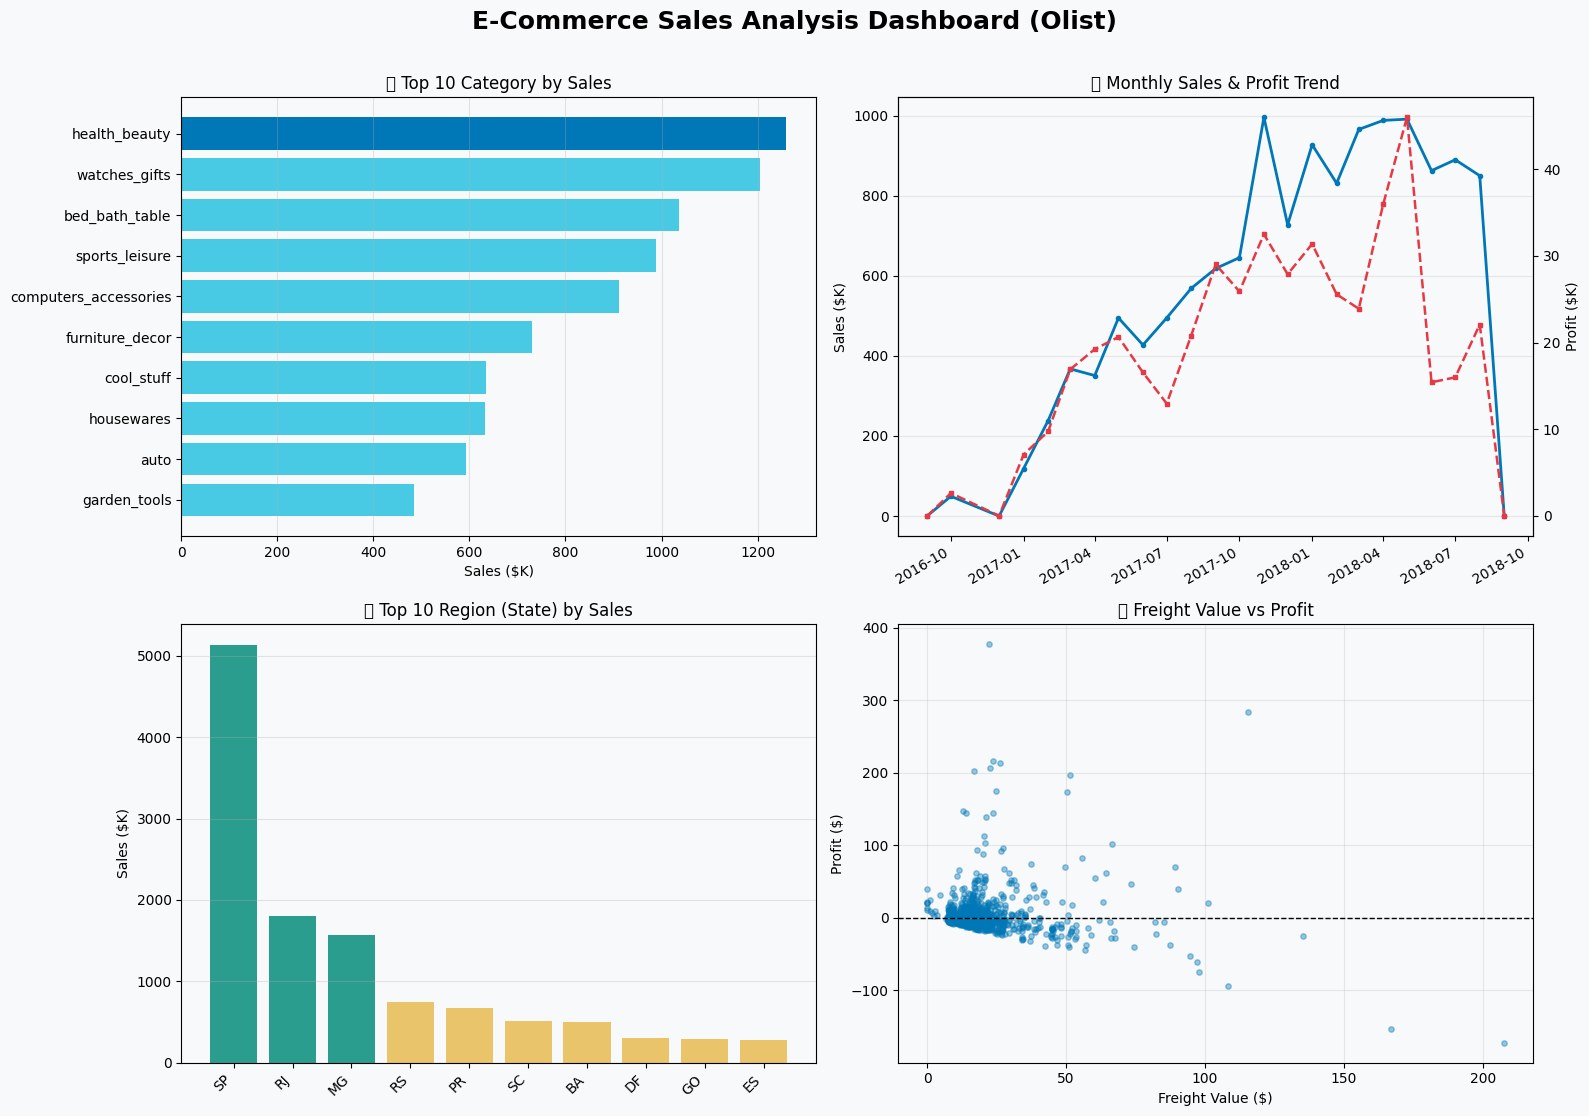

✅ Dashboard tersimpan!


In [6]:
FIG_COLOR = "#F8F9FA"

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(FIG_COLOR)
fig.suptitle("E-Commerce Sales Analysis Dashboard (Olist)", fontsize=18, fontweight="bold", y=1.01)

# Chart 1 - Top 10 Category by Sales
ax1 = axes[0,0]
ax1.set_facecolor(FIG_COLOR)
top_cat = sales_by_cat.head(10)
colors1 = ["#0077B6" if i == 0 else "#48CAE4" for i in range(len(top_cat))]
ax1.barh(top_cat.index, top_cat["Total_Sales"]/1e3, color=colors1)
ax1.set_xlabel("Sales ($K)")
ax1.set_title("🛒 Top 10 Category by Sales")
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

# Chart 2 - Monthly Sales Trend
ax2 = axes[0,1]
ax2.set_facecolor(FIG_COLOR)
monthly = df.groupby(["Year","Month"]).agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
monthly["Date"] = pd.to_datetime(monthly[["Year","Month"]].assign(Day=1))
monthly = monthly.sort_values("Date")
ax2.plot(monthly["Date"], monthly["Sales"]/1e3, color="#0077B6", lw=2, marker="o", ms=3, label="Sales")
ax2b = ax2.twinx()
ax2b.plot(monthly["Date"], monthly["Profit"]/1e3, color="#E63946", lw=1.8, ls="--", ms=3, marker="s", label="Profit")
ax2.set_title("📈 Monthly Sales & Profit Trend")
ax2.set_ylabel("Sales ($K)")
ax2b.set_ylabel("Profit ($K)")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
ax2.grid(axis="y", alpha=0.25)

# Chart 3 - Top 10 Region by Sales
ax3 = axes[1,0]
ax3.set_facecolor(FIG_COLOR)
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).head(10)
colors3 = ["#2A9D8F" if v > region_sales.mean() else "#E9C46A" for v in region_sales]
ax3.bar(region_sales.index, region_sales/1e3, color=colors3)
ax3.set_title("🗺️ Top 10 Region (State) by Sales")
ax3.set_ylabel("Sales ($K)")
ax3.grid(axis="y", alpha=0.3)
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right")

# Chart 4 - Freight vs Profit Scatter
ax4 = axes[1,1]
ax4.set_facecolor(FIG_COLOR)
sample = df.sample(min(1000, len(df)), random_state=42)
ax4.scatter(sample["freight_value"], sample["Profit"], alpha=0.4, color="#0077B6", s=15)
ax4.axhline(0, color="black", lw=1, ls="--")
ax4.set_title("🚚 Freight Value vs Profit")
ax4.set_xlabel("Freight Value ($)")
ax4.set_ylabel("Profit ($)")
ax4.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("dashboard_olist.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard tersimpan!")

# Cell 7 ; Heatmap

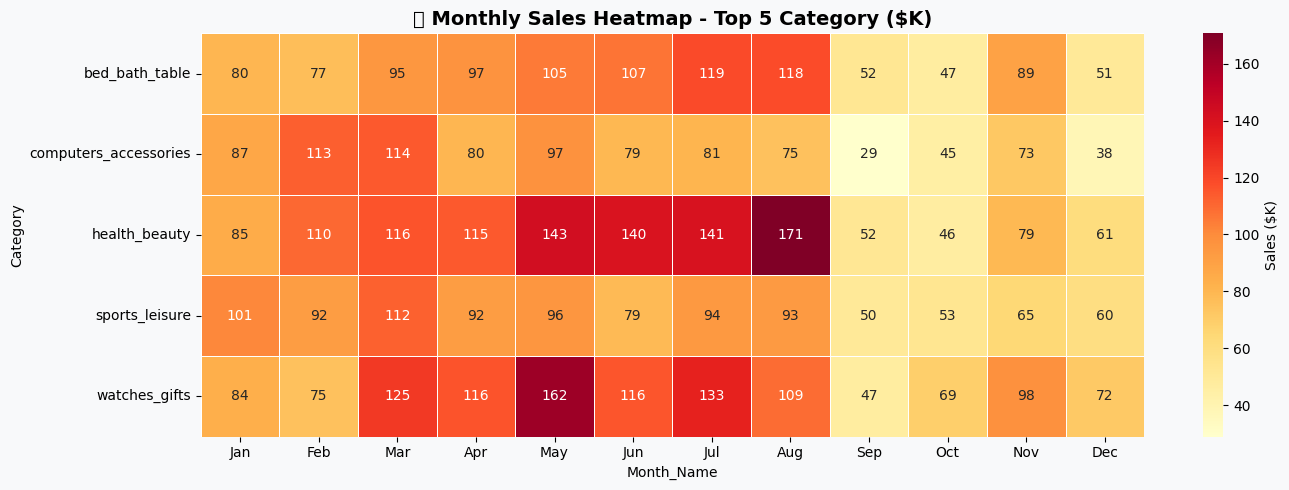

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(FIG_COLOR)

top5_cat = sales_by_cat.head(5).index.tolist()
heatmap_data = df[df["Category"].isin(top5_cat)].groupby(["Category","Month_Name"])["Sales"].sum().unstack()

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
heatmap_data = heatmap_data.reindex(columns=[m for m in month_order if m in heatmap_data.columns])

sns.heatmap(heatmap_data/1e3, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Sales ($K)"})
ax.set_title("🗓️ Monthly Sales Heatmap - Top 5 Category ($K)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_olist.png", dpi=150, bbox_inches="tight")
plt.show()

# Cell 8 ; Challenge Tasks

In [19]:
# Task 1: CLV
clv = df.groupby("customer_unique_id")["Sales"].agg(["sum","count"])
clv.columns = ["Total_Spend","Num_Orders"]
clv["Avg_Order"] = clv["Total_Spend"] / clv["Num_Orders"]
customer_mapping = {uid: f"Customer-{i+1:04d}" for i, uid in enumerate(clv.index)}
clv.index = clv.index.map(customer_mapping)
print("=== TOP 10 CUSTOMER (CLV) ===")
print(clv.sort_values("Total_Spend", ascending=False).head(10))

# Task 2: Top 5 Kategori Paling Rugi
print("\n=== TOP 5 KATEGORI PALING RUGI ===")
print(df.groupby("Category")["Profit"].sum().sort_values().head(5))

# Task 3: Profitabilitas per Region
print("\n=== PROFITABILITAS PER REGION (TOP 10) ===")
print(df.groupby("Region").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).sort_values("Sales", ascending=False).head(10))

=== TOP 10 CUSTOMER (CLV) ===
                    Total_Spend  Num_Orders  Avg_Order
customer_unique_id                                    
Customer-3749           13440.0           8    1680.00
Customer-80269           7388.0           2    3694.00
Customer-43516           7160.0           4    1790.00
Customer-81099           6735.0           1    6735.00
Customer-25652           6729.0           1    6729.00
Customer-93807           6499.0           1    6499.00
Customer-23618           5934.6           6     989.10
Customer-87828           4690.0           1    4690.00
Customer-34343           4599.9           2    2299.95
Customer-26866           4590.0           1    4590.00

=== TOP 5 KATEGORI PALING RUGI ===
Category
furniture_decor    -26796.802
housewares         -19699.378
electronics        -14528.972
office_furniture   -13779.810
telephony           -6482.284
Name: Profit, dtype: float64

=== PROFITABILITAS PER REGION (TOP 10) ===
             Sales      Profit
Region     